In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import  ColumnTransformer, make_column_transformer, make_column_selector
from sklearn.metrics import r2_score, log_loss, accuracy_score, roc_auc_score, f1_score, log_loss, classification_report

from sklearn.tree import DecisionTreeRegressor, plot_tree, DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression, ElasticNet, Ridge
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from xgboost import XGBClassifier, XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer 
from sklearn.decomposition import PCA     #**

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, StackingClassifier, StackingRegressor

from tqdm import tqdm  # Provides the progress of model running
import os
import warnings
warnings.filterwarnings('ignore')

In [8]:
wiscosin = pd.read_csv("D:/Machine_Learning/Cases/Wisconsin/BreastCancer.csv",index_col=0)
y = wiscosin["Class"]
X = wiscosin.drop('Class', axis=1)

In [9]:
prcomp = PCA().set_output(transform='pandas')
X_pca = prcomp.fit_transform(X)
X.shape, X_pca.shape

((699, 9), (699, 9))

In [10]:
np.cumsum(prcomp.explained_variance_ratio_)*100

array([ 68.92148641,  76.17490546,  82.27277194,  86.70847108,
        90.60818755,  94.06577109,  96.59348125,  98.86016534,
       100.        ])

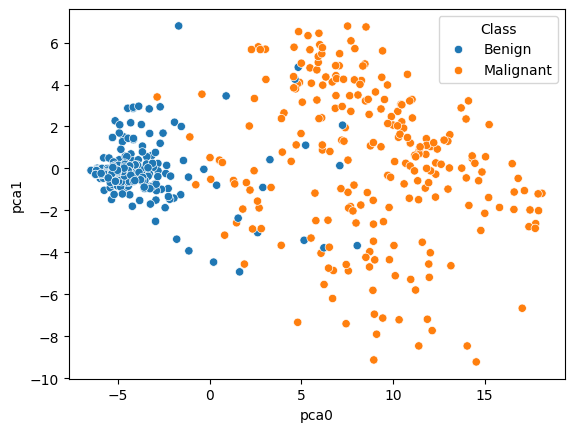

In [14]:
pc_data = X_pca.copy()
pc_data["Class"] = y
sns.scatterplot(data = pc_data, x='pca0', y='pca1', hue='Class')
plt.show()

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state=42, stratify=y)

In [19]:
prcomp = PCA().set_output(transform='pandas')
X_trn_pca = prcomp.fit_transform(X_train)
X_trn_pca = X_trn_pca.iloc[:,:2]
X_tst_pca = prcomp.transform(X_test)
X_tst_pca = X_tst_pca.iloc[:,:2]

svm = SVC(kernel='linear')
svm.fit(X_trn_pca, y_train)
y_pred = svm.predict(X_tst_pca)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Benign       0.99      0.98      0.99       138
   Malignant       0.96      0.99      0.97        72

    accuracy                           0.98       210
   macro avg       0.98      0.98      0.98       210
weighted avg       0.98      0.98      0.98       210



# HR 

In [29]:
hr = pd.read_csv('D:/Machine_Learning/Cases/HumanResource/HR_comma_sep.csv')

X , y = hr.drop('left', axis=1), hr['left']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state=26, stratify= hr['left'])

In [30]:
ohe=OneHotEncoder(sparse_output=False,drop="first").set_output(transform="pandas")

trans = make_column_transformer(( ohe, make_column_selector(dtype_include=object)),     
                          remainder="passthrough",verbose_feature_names_out=False).set_output(transform="pandas")

scaler = StandardScaler().set_output(transform='pandas')
svm = SVC()
comps = np.arange(2,16)
scores = []

for c in tqdm(comps):
    prcomp = PCA(n_components=c).set_output(transform='pandas')
    pipe = Pipeline([('OHE',trans),('SCL',scaler),('PCA',prcomp),('SVM',svm)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    scores.append([c, accuracy_score(y_test, y_pred)])

df_scores = pd.DataFrame(scores, columns=['comps', 'accuracy_score' ])
df_scores.sort_values(['accuracy_score', 'comps'], ascending=[False,True])

100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:34<00:00,  2.50s/it]


,comps,accuracy_score
13,15,0.942654
12,14,0.941543
11,13,0.932874
10,12,0.930429
9,11,0.929318
7,9,0.926873
8,10,0.926650
5,7,0.926428
6,8,0.926206
4,6,0.925984


# Grid Search

In [35]:
scaler = StandardScaler().set_output(transform='pandas')
svm = SVC(kernel='linear')
prcomp = PCA().set_output(transform='pandas')
pipe = Pipeline([('OHE',trans),('SCL',scaler),('PCA',prcomp),('SVM',svm)])

params = {'PCA__n_components': np.arange(2,19)}
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=26)
gcv = GridSearchCV(estimator=pipe, param_grid=params, cv=kfold, n_jobs=-1)
gcv.fit(X, y)
gcv.best_params_, gcv.best_score_

({'PCA__n_components': np.int64(16)}, np.float64(0.7806602200733577))

In [34]:
scaler = StandardScaler().set_output(transform='pandas')
lr = LogisticRegression()
prcomp = PCA().set_output(transform='pandas')
pipe = Pipeline([('OHE',trans),('SCL',scaler),('PCA',prcomp),('LR',lr)])

params = {'PCA__n_components': np.arange(2,19)}
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=26)
gcv = GridSearchCV(estimator=pipe, param_grid=params, cv=kfold, n_jobs=-1)
gcv.fit(X, y)
gcv.best_params_, gcv.best_score_

({'PCA__n_components': np.int64(18)}, np.float64(0.7905968656218739))

In [36]:
scaler = StandardScaler().set_output(transform='pandas')
rf = RandomForestClassifier(random_state=26)
prcomp = PCA().set_output(transform='pandas')
pipe = Pipeline([('OHE',trans),('SCL',scaler),('PCA',prcomp),('RF',rf)])

params = {'PCA__n_components': np.arange(2,19)}
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=26)
gcv = GridSearchCV(estimator=pipe, param_grid=params, cv=kfold, n_jobs=-1)
gcv.fit(X, y)
gcv.best_params_, gcv.best_score_

({'PCA__n_components': np.int64(17)}, np.float64(0.98432810936979))

In [37]:
scaler = StandardScaler().set_output(transform='pandas')
dtc = DecisionTreeClassifier(random_state=26)
prcomp = PCA().set_output(transform='pandas')
pipe = Pipeline([('OHE',trans),('SCL',scaler),('PCA',prcomp),('DTC',dtc)])

params = {'PCA__n_components': np.arange(2,19)}
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=26)
gcv = GridSearchCV(estimator=pipe, param_grid=params, cv=kfold, n_jobs=-1)
gcv.fit(X, y)
gcv.best_params_, gcv.best_score_

({'PCA__n_components': np.int64(16)}, np.float64(0.964921640546849))